In [1]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.2.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.81.1-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
df = pd.read_csv("../data/processed/model_ready_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df["Target_Next_Return"] = df["NVDA_Close"].pct_change().shift(-1)

df = df.dropna()

print(df.shape)
df.head()

(3935, 46)


,Date,NVDA_Open,NVDA_High,NVDA_Low,NVDA_Close,NVDA_Volume,SP500_Open,SP500_High,SP500_Low,SP500_Close,...,NVDA_EMA_26,NVDA_MACD,NVDA_MACD_Signal,NVDA_Volatility_7,NVDA_Volatility_30,NVDA_Close_Lag_1,NVDA_Close_Lag_7,NVDA_Close_Lag_30,Target_Next_Close,Target_Next_Return
0,2010-05-12,0.331948,0.337900,0.329887,0.336068,9.012360e+08,1155.430054,1172.869995,1155.430054,1171.670044,...,0.361494,-0.016927,-0.013719,0.030320,0.023612,0.329658,0.355756,0.403602,0.335382,-0.002044
1,2010-05-13,0.334695,0.350033,0.332177,0.335382,1.252000e+09,1170.040039,1173.569946,1156.140015,1157.439941,...,0.359560,-0.016406,-0.014256,0.023620,0.023581,0.336068,0.337671,0.398337,0.296693,-0.115358
2,2010-05-14,0.312718,0.313633,0.288451,0.296693,2.493068e+09,1157.189941,1157.189941,1126.140015,1135.680054,...,0.354903,-0.018897,-0.015184,0.049732,0.030970,0.335382,0.331948,0.394216,0.297379,0.002314
3,2010-05-17,0.297150,0.301042,0.287993,0.297379,8.560600e+08,1136.520020,1141.880005,1114.959961,1136.939941,...,0.350642,-0.020579,-0.016263,0.050036,0.030715,0.296693,0.325080,0.400169,0.287535,-0.033102
4,2010-05-18,0.299897,0.301729,0.285933,0.287535,6.741120e+08,1138.780029,1148.660034,1117.199951,1120.800049,...,0.345967,-0.022447,-0.017500,0.050698,0.030899,0.297379,0.319586,0.390325,0.292114,0.015924


In [43]:
feature_cols = [
    "NVDA_Close",
    "NVDA_Volume",
    "SP500_Close",
    "Gold_Close",
    "Oil_Close",
    "Treasury10Y_Close",
    "VIX_Close",
    "NVDA_Return",
    "NVDA_SMA_7",
    "NVDA_SMA_30",
    "NVDA_SMA_90",
    "NVDA_EMA_12",
    "NVDA_EMA_26",
    "NVDA_MACD",
    "NVDA_MACD_Signal",
    "NVDA_Volatility_7",
    "NVDA_Volatility_30",
    "NVDA_Close_Lag_1",
    "NVDA_Close_Lag_7",
    "NVDA_Close_Lag_30"
]

df["Target_Next_Return"] = df["NVDA_Close"].pct_change().shift(-1)
df = df.dropna()

target_col = "Target_Next_Return"

data = df[["Date"] + feature_cols + ["Target_Next_Close", target_col]].dropna().copy()

print(data.shape)

(3932, 23)


In [44]:
split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print("Train:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Test:", test_data["Date"].min(), "to", test_data["Date"].max())

Train: 2010-05-12 00:00:00 to 2022-11-04 00:00:00
Test: 2022-11-07 00:00:00 to 2025-12-23 00:00:00


In [45]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(train_data[feature_cols])
X_test_scaled = feature_scaler.transform(test_data[feature_cols])

y_train_scaled = target_scaler.fit_transform(train_data[[target_col]])
y_test_scaled = target_scaler.transform(test_data[[target_col]])

In [46]:
def create_sequences(X, y, time_steps=60):
    Xs, ys = [], []

    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])

    return np.array(Xs), np.array(ys)

time_steps = 60

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (3085, 60, 20)
y_train_seq: (3085, 1)
X_test_seq: (727, 60, 20)
y_test_seq: (727, 1)


In [47]:
model = Sequential()

model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=32,
    return_sequences=False
))
model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0093 - val_loss: 0.0068
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0048 - val_loss: 0.0067
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0044 - val_loss: 0.0061
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0039 - val_loss: 0.0061
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0036 - val_loss: 0.0061
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 0.0035 - val_loss: 0.0075
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0034 - val_loss: 0.0070
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0034 - val_loss: 0.0063
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0033 - val_loss: 0.0061
Epoch 10/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0032 - val_loss: 0.0063
Epoch 11/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0032 - val_loss: 0.0060
Epoch 12/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0

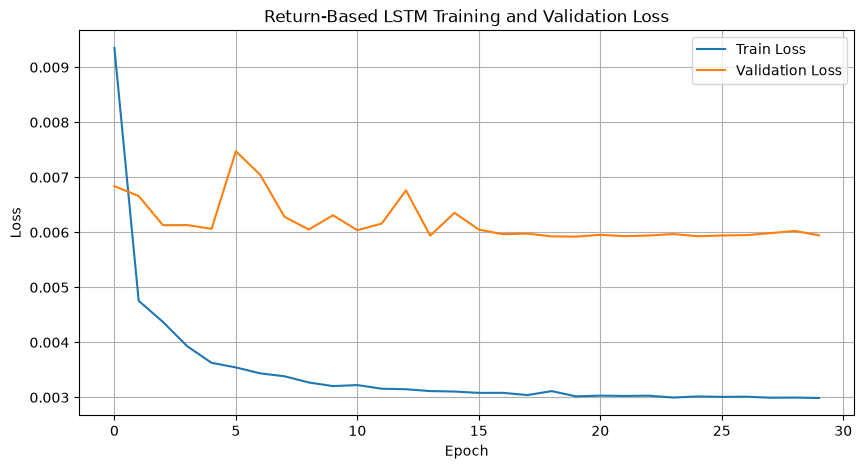

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Return-Based LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
pred_return_scaled = model.predict(X_test_seq)

pred_return = target_scaler.inverse_transform(pred_return_scaled).flatten()
actual_return = target_scaler.inverse_transform(y_test_seq).flatten()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [51]:
aligned_test_data = test_data.iloc[time_steps:].copy()

today_close = aligned_test_data["NVDA_Close"].values
actual_next_close = aligned_test_data["Target_Next_Close"].values

pred_next_close = today_close * (1 + pred_return)

In [52]:
mae = mean_absolute_error(actual_next_close, pred_next_close)
rmse = np.sqrt(mean_squared_error(actual_next_close, pred_next_close))
r2 = r2_score(actual_next_close, pred_next_close)
mape = np.mean(np.abs((actual_next_close - pred_next_close) / actual_next_close)) * 100

print("Return-Based LSTM Price Prediction Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAPE:", mape)

Return-Based LSTM Price Prediction Results
MAE: 2.7374088801255696
RMSE: 3.926313343560639
R2 Score: 0.9943714920707455
MAPE: 2.54804259948085


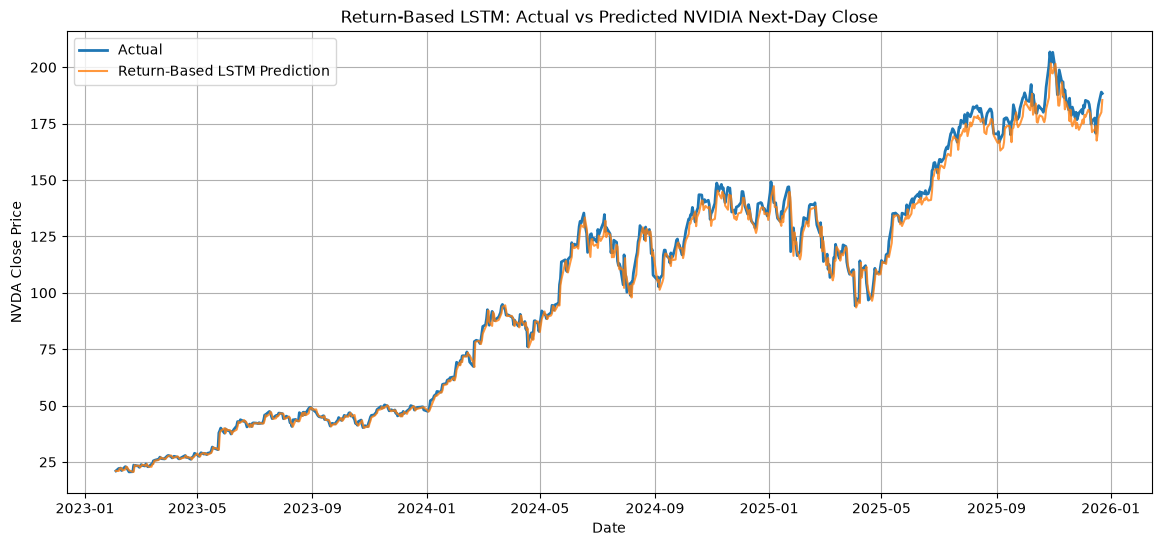

In [54]:
dates_test = aligned_test_data["Date"]

plt.figure(figsize=(14, 6))
plt.plot(dates_test, actual_next_close, label="Actual", linewidth=2)
plt.plot(dates_test, pred_next_close, label="Return-Based LSTM Prediction", alpha=0.8)

plt.title("Return-Based LSTM: Actual vs Predicted NVIDIA Next-Day Close")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.legend()
plt.grid(True)
plt.show()

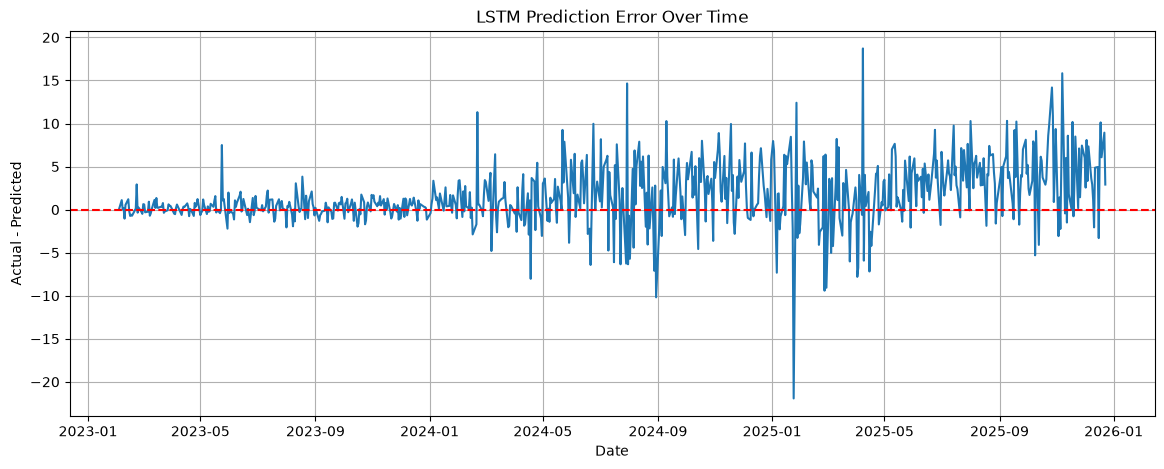

In [55]:
errors = actual_next_close - pred_next_close

plt.figure(figsize=(14, 5))
plt.plot(dates_test, errors)
plt.axhline(0, color="red", linestyle="--")

plt.title("LSTM Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.grid(True)
plt.show()

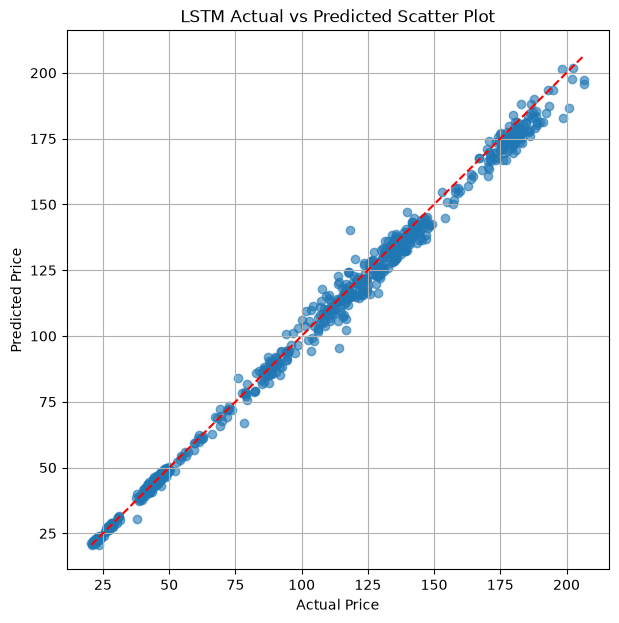

In [56]:
plt.figure(figsize=(7, 7))
plt.scatter(actual_next_close, pred_next_close, alpha=0.6)

min_val = min(actual_next_close.min(), pred_next_close.min())
max_val = max(actual_next_close.max(), pred_next_close.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.title("LSTM Actual vs Predicted Scatter Plot")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.show()

In [59]:
model_comparison = pd.DataFrame({
    "Model": [
        "Walk-Forward ARIMA",
        "Walk-Forward SARIMAX",
        "XGBoost Return-Based",
        "LSTM Return-Based"
    ],
    "MAE": [
        2.09,
        1.81,
        2.36,
        2.74
    ],
    "RMSE": [
        3.18,
        2.77,
        3.55,
        3.93
    ],
    "R2 Score": [
        0.9967,
        0.9975,
        0.9959,
        0.9944
    ],
    "MAPE": [
        2.28,
        1.91,
        2.56,
        2.55
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score,MAPE
0,Walk-Forward ARIMA,2.09,3.18,0.9967,2.28
1,Walk-Forward SARIMAX,1.81,2.77,0.9975,1.91
2,XGBoost Return-Based,2.36,3.55,0.9959,2.56
3,LSTM Return-Based,2.74,3.93,0.9944,2.55


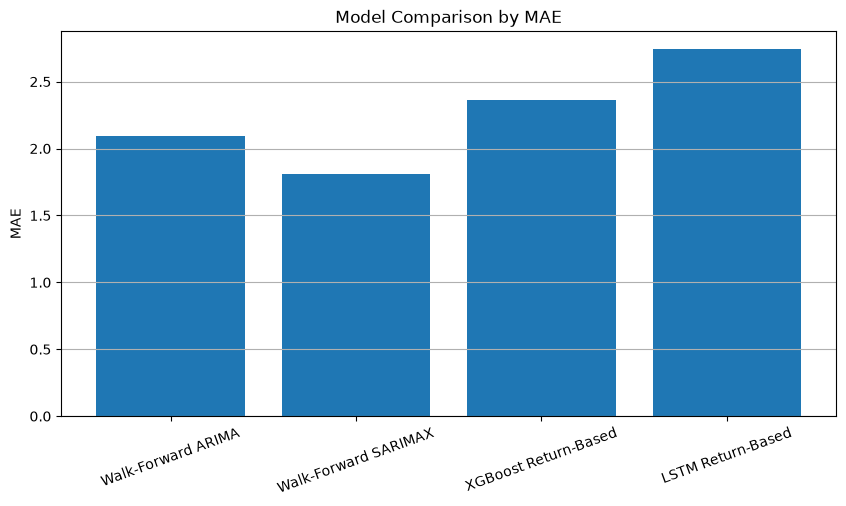

In [60]:
plt.figure(figsize=(10, 5))
plt.bar(model_comparison["Model"], model_comparison["MAE"])

plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()